**生成式 AI 的使用**：在本作业中，生成式 AI 的使用须遵循与协作相同的政策。与其他协作者一样，每位学生都必须独立于交互输出自行写出解答，并且提交内容中应附注说明协作的性质。使用生成式 AI 工具完成作业的大部分内容不符合本作业的初衷，并将违反[荣誉准则](https://communitystandards.stanford.edu/policies-and-guidance/honor-code)。

**学生声明（必须填写）**

**SUNet id：**  
_你的 SUNet id_

**你是否使用了生成式 AI 工具（例如 ChatGPT、Copilot 等）？**  
- [ ] 否  
- [ ] 是（请在下方说明）

**如果是，请说明你如何使用生成式 AI，以及将其用于作业的哪些部分：**  
_你的回答_

**请确认所有提交的内容都反映了你自己的理解，并且你没有依赖 AI 完成作业的大部分内容：**  
- [ ] 我确认

In [ ]:
# This mounts your Google Drive to the Colab VM.
from google.colab import drive
drive.mount('/content/drive')

# TODO: Enter the foldername in your Drive where you have saved the unzipped
# assignment folder, e.g. 'cs231n/assignments/assignment2/'
FOLDERNAME = 'cs231n/assignments/assignment2/'
assert FOLDERNAME is not None, "[!] Enter the foldername."

# Now that we've mounted your Drive, this ensures that
# the Python interpreter of the Colab VM can load
# python files from within it.
import sys
sys.path.append('/content/drive/My Drive/{}'.format(FOLDERNAME))

# This downloads the CIFAR-10 dataset to your Drive
# if it doesn't already exist.
%cd /content/drive/My\ Drive/$FOLDERNAME/cs231n/datasets/
!bash get_datasets.sh
%cd /content/drive/My\ Drive/$FOLDERNAME

# 批量归一化

让深度网络更易训练的一种方法，是使用更先进的优化方法，例如 SGD+momentum、RMSProp 或 Adam。另一种策略是改变网络架构，使其更易训练。沿着这一思路，[1] 在 2015 年提出了批量归一化（batch normalization）。

要理解批量归一化的目标，首先要认识到：当输入数据由均值为零、方差为一且彼此不相关的特征组成时，机器学习方法往往表现得更好。训练神经网络时，我们可以在将数据送入网络之前对其进行预处理，显式地去除特征之间的相关性。这能确保网络第一层看到的数据具有良好的分布。然而，即使我们对输入数据进行了预处理，网络更深层的激活值也很可能不再彼此不相关，也不再具有零均值或单位方差，因为它们是网络前面各层的输出。更糟的是，在训练过程中，随着每一层的权重不断更新，网络各层的特征分布也会发生变化。

[1] 的作者推测，深度神经网络内部不断变化的特征分布可能会增加深度网络的训练难度。为了解决这个问题，他们提出在网络中插入对批数据进行归一化的层。训练时，这种层使用一个小批量数据来估计每个特征的均值和标准差，然后用这些估计值对该小批量的特征进行居中和归一化。训练期间会维护这些均值和标准差的滑动平均值；测试时，则使用这些滑动平均值对特征进行居中和归一化。

这种归一化策略可能会降低网络的表示能力，因为对某些层而言，特征不具有零均值或单位方差有时可能才是最优的。为此，批量归一化层为每个特征维度加入了可学习的偏移参数和缩放参数。

[1] [Sergey Ioffe and Christian Szegedy, “Batch Normalization: Accelerating Deep Network Training by Reducing
Internal Covariate Shift”, ICML 2015.](https://arxiv.org/abs/1502.03167)

In [1]:
# Setup cell.
import time
import numpy as np
import matplotlib.pyplot as plt
from cs231n.data_utils import get_CIFAR10_data
from cs231n.gradient_check import eval_numerical_gradient, eval_numerical_gradient_array
from cs231n.solver import Solver

%matplotlib inline
plt.rcParams["figure.figsize"] = (10.0, 8.0)  # Set default size of plots.
plt.rcParams["image.interpolation"] = "nearest"
plt.rcParams["image.cmap"] = "gray"

import sys
import types
import importlib

if "imp" not in sys.modules:
    imp = types.ModuleType("imp")
    imp.reload = importlib.reload
    sys.modules["imp"] = imp

%load_ext autoreload
%autoreload 2

def rel_error(x, y):
    """Returns relative error."""
    return np.max(np.abs(x - y) / (np.maximum(1e-8, np.abs(x) + np.abs(y))))

def print_mean_std(x,axis=0):
    print(f"  means: {x.mean(axis=axis)}")
    print(f"  stds:  {x.std(axis=axis)}\n")

In [2]:
# Load the (preprocessed) CIFAR-10 data.
data = get_CIFAR10_data()
for k, v in list(data.items()):
    print(f"{k}: {v.shape}")

X_train: (49000, 3, 32, 32)
y_train: (49000,)
X_val: (1000, 3, 32, 32)
y_val: (1000,)
X_test: (1000, 3, 32, 32)
y_test: (1000,)


# 批量归一化：前向传播

请在文件 `cs231n/layers.py` 的函数 `batchnorm_forward` 中实现批量归一化的前向传播。完成后，运行以下代码测试你的实现。

参考上方 [1] 链接的论文可能会有所帮助！

In [3]:
from cs231n.layers import *

# Check the training-time forward pass by checking means and variances
# of features both before and after batch normalization

# Simulate the forward pass for a two-layer network.
np.random.seed(231)
N, D1, D2, D3 = 200, 50, 60, 3
X = np.random.randn(N, D1)
W1 = np.random.randn(D1, D2)
W2 = np.random.randn(D2, D3)
a = np.maximum(0, X.dot(W1)).dot(W2)

print('Before batch normalization:')
print_mean_std(a,axis=0)

gamma = np.ones((D3,))
beta = np.zeros((D3,))

# Means should be close to zero and stds close to one.
print('After batch normalization (gamma=1, beta=0)')
a_norm, _ = batchnorm_forward(a, gamma, beta, {'mode': 'train'})
print_mean_std(a_norm,axis=0)

gamma = np.asarray([1.0, 2.0, 3.0])
beta = np.asarray([11.0, 12.0, 13.0])

# Now means should be close to beta and stds close to gamma.
print('After batch normalization (gamma=', gamma, ', beta=', beta, ')')
a_norm, _ = batchnorm_forward(a, gamma, beta, {'mode': 'train'})
print_mean_std(a_norm,axis=0)

Before batch normalization:
  means: [ -2.3814598  -13.18038246   1.91780462]
  stds:  [27.18502186 34.21455511 37.68611762]

After batch normalization (gamma=1, beta=0)
  means: [ 3.10862447e-17 -3.94129174e-17  3.29597460e-17]
  stds:  [0.99999999 1.         1.        ]

After batch normalization (gamma= [1. 2. 3.] , beta= [11. 12. 13.] )
  means: [11. 12. 13.]
  stds:  [0.99999999 1.99999999 2.99999999]



In [4]:
# Check the test-time forward pass by running the training-time
# forward pass many times to warm up the running averages, and then
# checking the means and variances of activations after a test-time
# forward pass.

np.random.seed(231)
N, D1, D2, D3 = 200, 50, 60, 3
W1 = np.random.randn(D1, D2)
W2 = np.random.randn(D2, D3)

bn_param = {'mode': 'train'}
gamma = np.ones(D3)
beta = np.zeros(D3)

for t in range(50):
  X = np.random.randn(N, D1)
  a = np.maximum(0, X.dot(W1)).dot(W2)
  batchnorm_forward(a, gamma, beta, bn_param)

bn_param['mode'] = 'test'
X = np.random.randn(N, D1)
a = np.maximum(0, X.dot(W1)).dot(W2)
a_norm, _ = batchnorm_forward(a, gamma, beta, bn_param)

# Means should be close to zero and stds close to one, but will be
# noisier than training-time forward passes.
print('After batch normalization (test-time):')
print_mean_std(a_norm,axis=0)

After batch normalization (test-time):
  means: [-0.03927354 -0.04349152 -0.10452688]
  stds:  [1.01531428 1.01238373 0.97819988]



# 批量归一化：反向传播

现在，请在函数 `batchnorm_backward` 中实现批量归一化的反向传播。

为了推导反向传播，你应画出批量归一化的计算图，并对每个中间节点执行反向传播。有些中间量可能有多个向外分支；请确保在反向传播中将这些分支上的梯度相加。参考上方 [1] 链接的论文可能会有所帮助！

完成后，运行以下代码，对你的反向传播进行数值检查。

_提示：[这篇文章](https://www.adityaagrawal.net/blog/deep_learning/bprop_batch_norm)是一个很有用的资源，介绍了如何从论文中的公式推导梯度。_

In [5]:
# Gradient check batchnorm backward pass.
np.random.seed(231)
N, D = 4, 5
x = 5 * np.random.randn(N, D) + 12
gamma = np.random.randn(D)
beta = np.random.randn(D)
dout = np.random.randn(N, D)

bn_param = {'mode': 'train'}
fx = lambda x: batchnorm_forward(x, gamma, beta, bn_param)[0]
fg = lambda a: batchnorm_forward(x, a, beta, bn_param)[0]
fb = lambda b: batchnorm_forward(x, gamma, b, bn_param)[0]

dx_num = eval_numerical_gradient_array(fx, x, dout)
da_num = eval_numerical_gradient_array(fg, gamma.copy(), dout)
db_num = eval_numerical_gradient_array(fb, beta.copy(), dout)

_, cache = batchnorm_forward(x, gamma, beta, bn_param)
dx, dgamma, dbeta = batchnorm_backward(dout, cache)

# You should expect to see relative errors between 1e-13 and 1e-8.
print('dx error: ', rel_error(dx_num, dx))
print('dgamma error: ', rel_error(da_num, dgamma))
print('dbeta error: ', rel_error(db_num, dbeta))

dx error:  1.7029258328157158e-09
dgamma error:  7.420414216247087e-13
dbeta error:  2.8795057655839487e-12


# 批量归一化：另一种反向传播

课堂上，我们讨论了 sigmoid 反向传播的两种不同实现方式。一种策略是写出由简单操作构成的计算图，并对所有中间值进行反向传播。另一种策略是在纸上推导导数。例如，通过在纸上化简梯度，可以为 sigmoid 函数的反向传播推导出一个非常简洁的公式。

令人惊讶的是，批量归一化的反向传播也可以进行类似的化简！  

在前向传播中，给定一组输入 $X=\begin{bmatrix}x_1\\x_2\\...\\x_N\end{bmatrix}$，

我们首先计算均值 $\mu$ 和方差 $v$。
计算出 $\mu$ 和 $v$ 后，即可计算标准差 $\sigma$ 和归一化数据 $Y$。
下面的公式和示意图描述了这一计算过程（$y_i$ 是向量 $Y$ 的第 i 个元素）。

\begin{align}
& \mu=\frac{1}{N}\sum_{k=1}^N x_k  &  v=\frac{1}{N}\sum_{k=1}^N (x_k-\mu)^2 \\
& \sigma=\sqrt{v+\epsilon}         &  y_i=\frac{x_i-\mu}{\sigma}
\end{align}

<img src="https://raw.githubusercontent.com/cs231n/cs231n.github.io/master/assets/a2/batchnorm_graph.png">

反向传播过程中，问题的核心是：给定接收到的上游梯度 $\frac{\partial L}{\partial Y}$，计算 $\frac{\partial L}{\partial X}$。为此，回顾微积分中的链式法则：$\frac{\partial L}{\partial X} = \frac{\partial L}{\partial Y} \cdot \frac{\partial Y}{\partial X}$。

其中未知且困难的部分是 $\frac{\partial Y}{\partial X}$。我们可以先逐步推导局部梯度
$\frac{\partial v}{\partial X}$、$\frac{\partial \mu}{\partial X}$、
$\frac{\partial \sigma}{\partial v}$、
$\frac{\partial Y}{\partial \sigma}$ 和 $\frac{\partial Y}{\partial \mu}$，
然后使用链式法则，以适当的方式组合这些梯度（它们会以向量形式出现！），从而计算 $\frac{\partial Y}{\partial X}$。

如果很难直接分析需要矩阵乘法的 $X$ 和 $Y$ 上的梯度，可以先从单个元素 $x_i$ 和 $y_i$ 的角度思考：此时需要推导 $\frac{\partial L}{\partial x_i}$，即利用链式法则先计算中间项 $\frac{\partial \mu}{\partial x_i}, \frac{\partial v}{\partial x_i}, \frac{\partial \sigma}{\partial x_i},$，再组合这些部分以计算 $\frac{\partial y_i}{\partial x_i}$。

为了便于实现，请确保每个中间梯度的推导都尽可能化简。

完成推导后，请在函数 `batchnorm_backward_alt` 中实现化简后的批量归一化反向传播，并运行以下代码比较两种实现。两种实现的计算结果应几乎完全相同，但另一种实现应稍快一些。

_提示：https://cs.stanford.edu/people/jcjohns/batchnorm.pdf。请注意，在最终推导中应将 γ 提取为因子。_

_请注意，此 pdf 中的公式 (8) 应为：_ 
$$\frac{1}{\sigma} \frac{\partial}{\partial x_i} (x_j - \mu)
- \frac{1}{\sigma^2} \frac{\partial \sigma}{\partial x_i} (x_j - \mu)$$

In [7]:
np.random.seed(231)
N, D = 100, 500
x = 5 * np.random.randn(N, D) + 12
gamma = np.random.randn(D)
beta = np.random.randn(D)
dout = np.random.randn(N, D)

bn_param = {'mode': 'train'}
out, cache = batchnorm_forward(x, gamma, beta, bn_param)

t1 = time.time()
dx1, dgamma1, dbeta1 = batchnorm_backward(dout, cache)
t2 = time.time()
dx2, dgamma2, dbeta2 = batchnorm_backward_alt(dout, cache)
t3 = time.time()

print('dx difference: ', rel_error(dx1, dx2))
print('dgamma difference: ', rel_error(dgamma1, dgamma2))
print('dbeta difference: ', rel_error(dbeta1, dbeta2))
print(t1,t2,t3)
print('speedup: %.2fx' % ((t2 - t1) / (t3 - t2)))

dx difference:  1.3630859035235324e-12
dgamma difference:  0.0
dbeta difference:  0.0
1788599902.1607933 1788599902.161792 1788599902.161792


ZeroDivisionError: float division by zero

# 使用批量归一化的全连接网络

现在你已经有了可用的批量归一化实现，请回到文件 `cs231n/classifiers/fc_net.py` 中的 `FullyConnectedNet`。回想一下，你在作业 1 中实现了网络初始化、前向传播和反向传播。将该实现复制到这里，并修改它以加入批量归一化。

具体来说，当构造函数中的 `normalization` 标志被设为 `"batchnorm"` 时，应在每个 ReLU 非线性之前插入一个批量归一化层。网络最后一层的输出不应被归一化。完成后，运行以下代码，对你的实现进行梯度检查。

**提示：**你可能会发现，定义一个类似于文件 `cs231n/layer_utils.py` 中那些辅助层的额外辅助层会很有用。

In [5]:
from cs231n.classifiers.fc_net import *
from cs231n.gradient_check import *

np.random.seed(231)
N, D, H1, H2, C = 2, 15, 20, 30, 10
X = np.random.randn(N, D)
y = np.random.randint(C, size=(N,))

# You should expect losses between 1e-4~1e-10 for W,
# losses between 1e-08~1e-10 for b,
# and losses between 1e-08~1e-09 for beta and gammas.
for reg in [0, 3.14]:
  print('Running check with reg = ', reg)
  model = FullyConnectedNet([H1, H2], input_dim=D, num_classes=C,
                            reg=reg, weight_scale=5e-2, dtype=np.float64,
                            normalization='batchnorm')

  loss, grads = model.loss(X, y)
  print('Initial loss: ', loss)

  for name in sorted(grads):
    f = lambda _: model.loss(X, y)[0]
    grad_num = eval_numerical_gradient(f, model.params[name], verbose=False, h=1e-5)
    print('%s relative error: %.2e' % (name, rel_error(grad_num, grads[name])))
  if reg == 0: print()

Running check with reg =  0
Initial loss:  2.2611955101340957
W1 relative error: 1.10e-04
W2 relative error: 5.65e-06
W3 relative error: 4.47e-10
b1 relative error: 2.66e-07
b2 relative error: 2.50e-07
b3 relative error: 1.77e-10

Running check with reg =  3.14
Initial loss:  6.996533220108303
W1 relative error: 1.98e-06
W2 relative error: 2.28e-06
W3 relative error: 1.00e+00
b1 relative error: 1.38e-08
b2 relative error: 2.86e-08
b3 relative error: 1.73e-10


# 深度网络中的批量归一化

运行以下代码，分别使用和不使用批量归一化，在 1000 个训练样本的子集上训练一个六层网络。

In [10]:
np.random.seed(231)

# Try training a very deep net with batchnorm.
hidden_dims = [100, 100, 100, 100, 100]
num_train = 1000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

weight_scale = 2e-2
bn_model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, normalization='batchnorm')
model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, normalization=None)

print('Solver with batch norm:')
bn_solver = Solver(bn_model, small_data,
                num_epochs=10, batch_size=50,
                update_rule='adam',
                optim_config={
                  'learning_rate': 1e-3,
                },
                verbose=True,print_every=20)
bn_solver.train()

print('\nSolver without batch norm:')
solver = Solver(model, small_data,
                num_epochs=10, batch_size=50,
                update_rule='adam',
                optim_config={
                  'learning_rate': 1e-3,
                },
                verbose=True, print_every=20)
solver.train()

Solver with batch norm:
(Iteration 1 / 200) loss: 2.340974
(Epoch 0 / 10) train acc: 0.107000; val_acc: 0.115000
(Epoch 1 / 10) train acc: 0.314000; val_acc: 0.266000
(Iteration 21 / 200) loss: 2.039365
(Epoch 2 / 10) train acc: 0.388000; val_acc: 0.277000
(Iteration 41 / 200) loss: 2.036942
(Epoch 3 / 10) train acc: 0.491000; val_acc: 0.321000
(Iteration 61 / 200) loss: 1.751340
(Epoch 4 / 10) train acc: 0.533000; val_acc: 0.321000
(Iteration 81 / 200) loss: 1.265543
(Epoch 5 / 10) train acc: 0.552000; val_acc: 0.311000
(Iteration 101 / 200) loss: 1.360013
(Epoch 6 / 10) train acc: 0.631000; val_acc: 0.329000
(Iteration 121 / 200) loss: 1.025871
(Epoch 7 / 10) train acc: 0.647000; val_acc: 0.323000
(Iteration 141 / 200) loss: 1.284473
(Epoch 8 / 10) train acc: 0.682000; val_acc: 0.294000
(Iteration 161 / 200) loss: 0.743006
(Epoch 9 / 10) train acc: 0.766000; val_acc: 0.316000
(Iteration 181 / 200) loss: 1.020284
(Epoch 10 / 10) train acc: 0.744000; val_acc: 0.293000

Solver without b

运行以下代码，将上面训练的两个网络的结果可视化。你应该会发现，使用批量归一化能帮助网络更快地收敛。

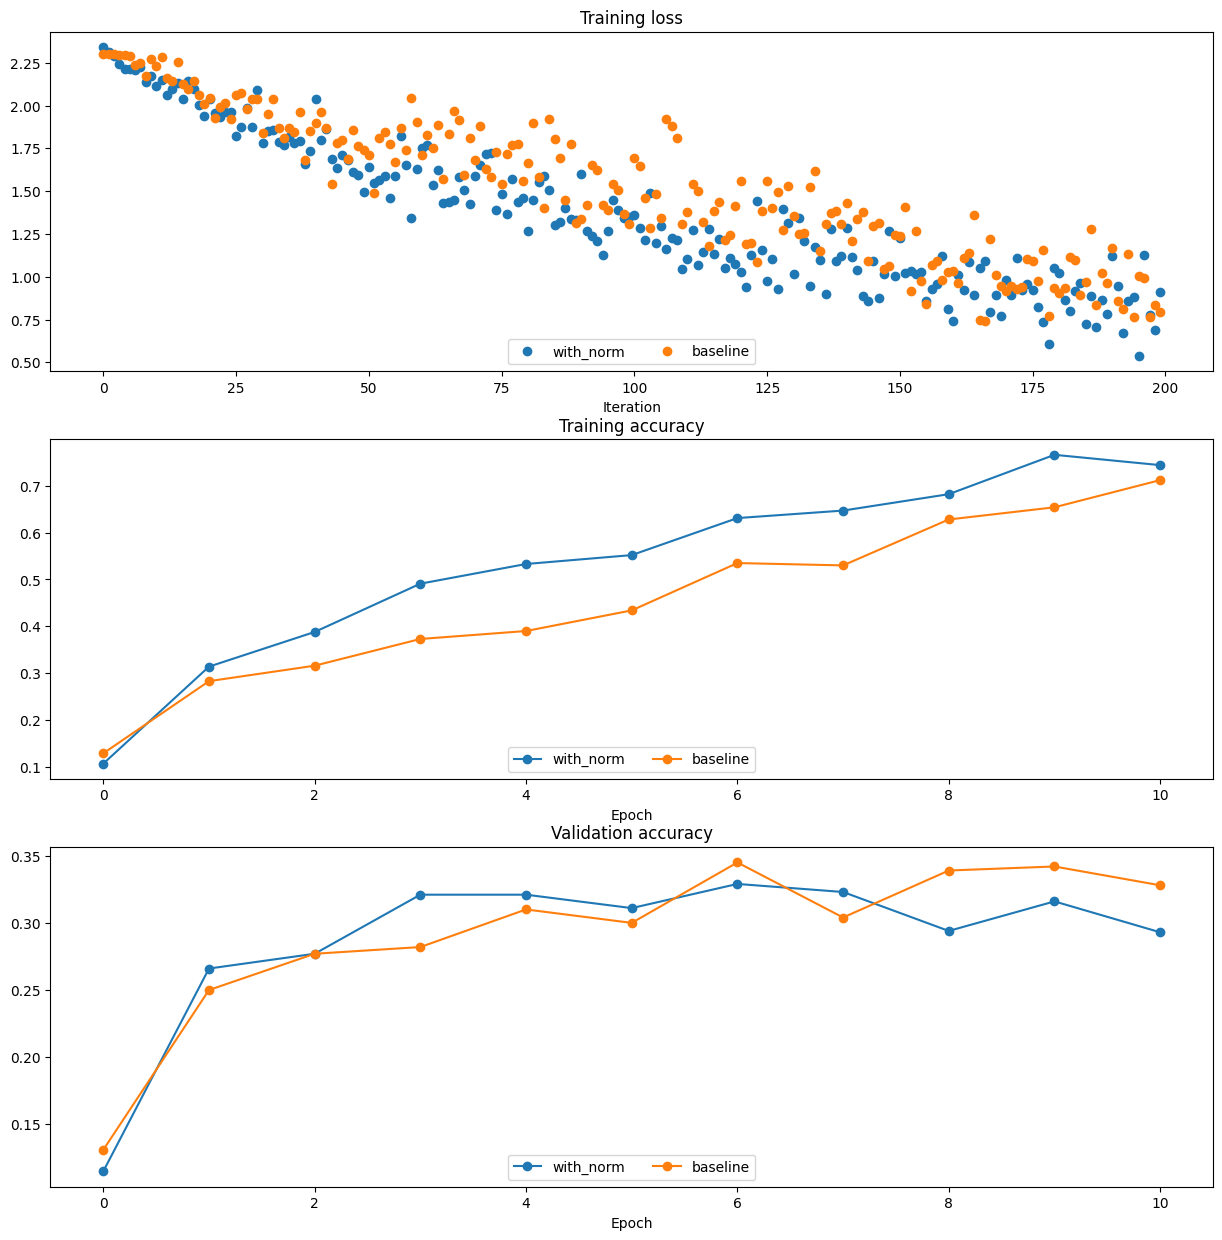

In [11]:
def plot_training_history(title, label, baseline, bn_solvers, plot_fn, bl_marker='.', bn_marker='.', labels=None):
    """utility function for plotting training history"""
    plt.title(title)
    plt.xlabel(label)
    bn_plots = [plot_fn(bn_solver) for bn_solver in bn_solvers]
    bl_plot = plot_fn(baseline)
    num_bn = len(bn_plots)
    for i in range(num_bn):
        label='with_norm'
        if labels is not None:
            label += str(labels[i])
        plt.plot(bn_plots[i], bn_marker, label=label)
    label='baseline'
    if labels is not None:
        label += str(labels[0])
    plt.plot(bl_plot, bl_marker, label=label)
    plt.legend(loc='lower center', ncol=num_bn+1)


plt.subplot(3, 1, 1)
plot_training_history('Training loss','Iteration', solver, [bn_solver], \
                      lambda x: x.loss_history, bl_marker='o', bn_marker='o')
plt.subplot(3, 1, 2)
plot_training_history('Training accuracy','Epoch', solver, [bn_solver], \
                      lambda x: x.train_acc_history, bl_marker='-o', bn_marker='-o')
plt.subplot(3, 1, 3)
plot_training_history('Validation accuracy','Epoch', solver, [bn_solver], \
                      lambda x: x.val_acc_history, bl_marker='-o', bn_marker='-o')

plt.gcf().set_size_inches(15, 15)
plt.show()

# 批量归一化与初始化

现在，我们将运行一个小实验，研究批量归一化与权重初始化之间的相互作用。

第一个单元会使用不同的权重初始化尺度，分别训练使用和不使用批量归一化的八层网络。第二个单元会绘制训练准确率、验证集准确率和训练损失随权重初始化尺度变化的曲线。

In [12]:
np.random.seed(231)

# Try training a very deep net with batchnorm.
hidden_dims = [50, 50, 50, 50, 50, 50, 50]
num_train = 1000
small_data = {
  'X_train': data['X_train'][:num_train],
  'y_train': data['y_train'][:num_train],
  'X_val': data['X_val'],
  'y_val': data['y_val'],
}

bn_solvers_ws = {}
solvers_ws = {}
weight_scales = np.logspace(-4, 0, num=20)
for i, weight_scale in enumerate(weight_scales):
    print('Running weight scale %d / %d' % (i + 1, len(weight_scales)))
    bn_model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, normalization='batchnorm')
    model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, normalization=None)

    bn_solver = Solver(bn_model, small_data,
                  num_epochs=10, batch_size=50,
                  update_rule='adam',
                  optim_config={
                    'learning_rate': 1e-3,
                  },
                  verbose=False, print_every=200)
    bn_solver.train()
    bn_solvers_ws[weight_scale] = bn_solver

    solver = Solver(model, small_data,
                  num_epochs=10, batch_size=50,
                  update_rule='adam',
                  optim_config={
                    'learning_rate': 1e-3,
                  },
                  verbose=False, print_every=200)
    solver.train()
    solvers_ws[weight_scale] = solver

Running weight scale 1 / 20
Running weight scale 2 / 20
Running weight scale 3 / 20
Running weight scale 4 / 20
Running weight scale 5 / 20
Running weight scale 6 / 20
Running weight scale 7 / 20
Running weight scale 8 / 20
Running weight scale 9 / 20
Running weight scale 10 / 20
Running weight scale 11 / 20
Running weight scale 12 / 20
Running weight scale 13 / 20
Running weight scale 14 / 20
Running weight scale 15 / 20
Running weight scale 16 / 20


c:\Users\lenovo\Desktop\cs by orbro\cs231n\assignment\assignment2\cs231n\layers.py:136: RuntimeWarning: divide by zero encountered in log
  loss =-np.mean(np.log(correct))


Running weight scale 17 / 20
Running weight scale 18 / 20
Running weight scale 19 / 20
Running weight scale 20 / 20


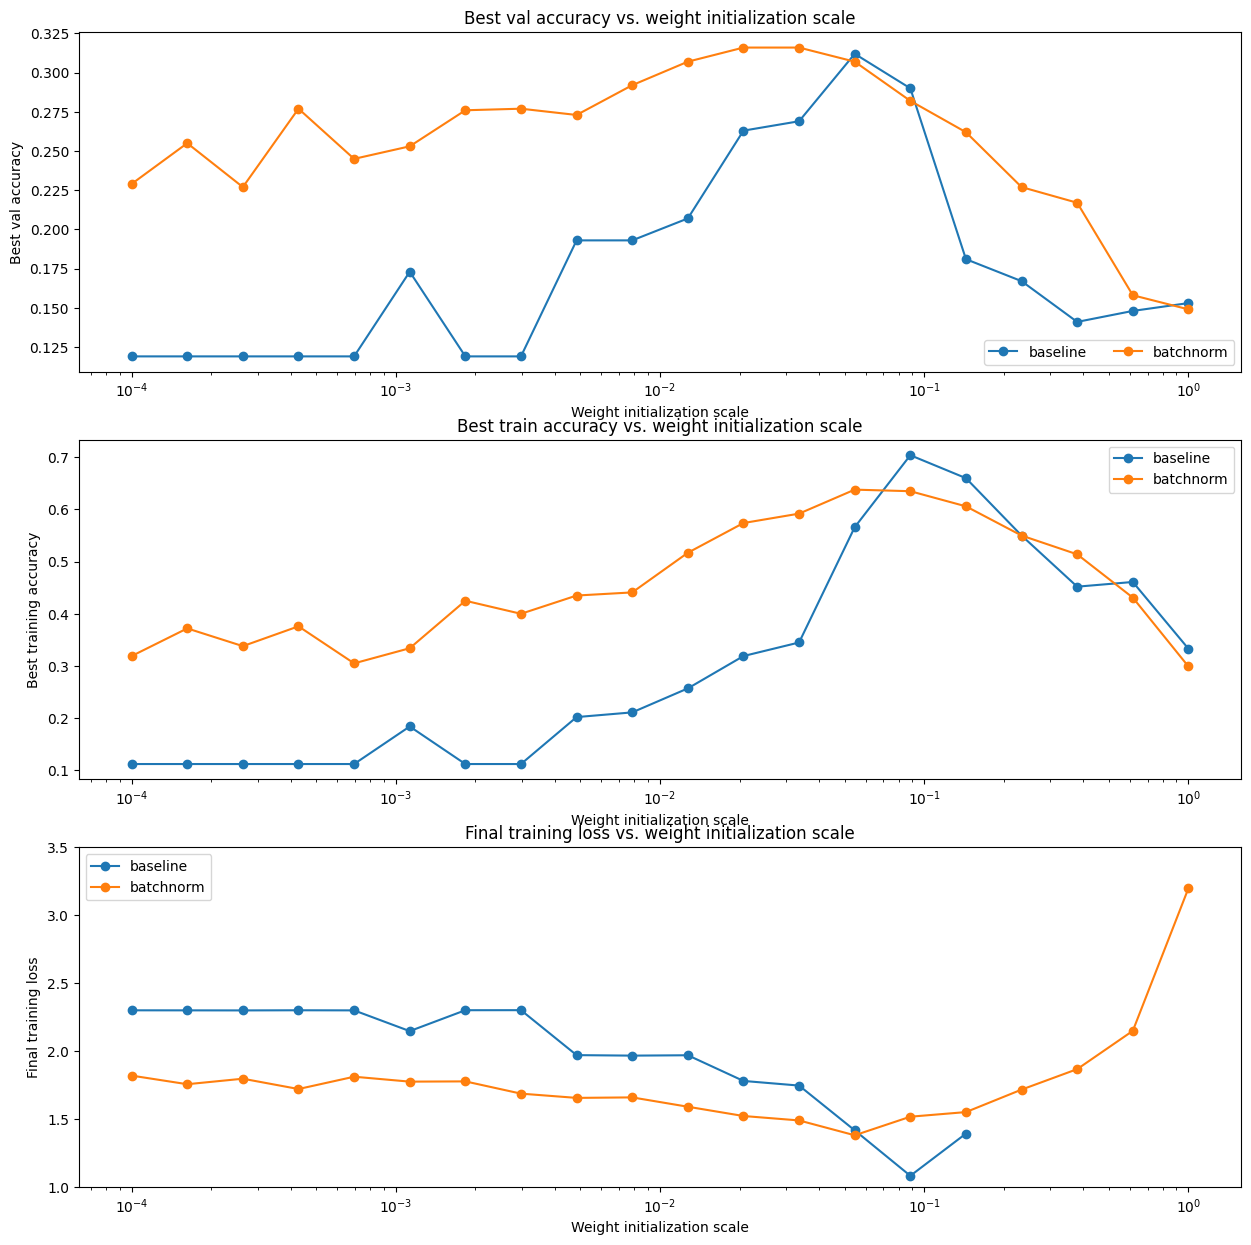

In [13]:
# Plot results of weight scale experiment.
best_train_accs, bn_best_train_accs = [], []
best_val_accs, bn_best_val_accs = [], []
final_train_loss, bn_final_train_loss = [], []

for ws in weight_scales:
  best_train_accs.append(max(solvers_ws[ws].train_acc_history))
  bn_best_train_accs.append(max(bn_solvers_ws[ws].train_acc_history))

  best_val_accs.append(max(solvers_ws[ws].val_acc_history))
  bn_best_val_accs.append(max(bn_solvers_ws[ws].val_acc_history))

  final_train_loss.append(np.mean(solvers_ws[ws].loss_history[-100:]))
  bn_final_train_loss.append(np.mean(bn_solvers_ws[ws].loss_history[-100:]))

plt.subplot(3, 1, 1)
plt.title('Best val accuracy vs. weight initialization scale')
plt.xlabel('Weight initialization scale')
plt.ylabel('Best val accuracy')
plt.semilogx(weight_scales, best_val_accs, '-o', label='baseline')
plt.semilogx(weight_scales, bn_best_val_accs, '-o', label='batchnorm')
plt.legend(ncol=2, loc='lower right')

plt.subplot(3, 1, 2)
plt.title('Best train accuracy vs. weight initialization scale')
plt.xlabel('Weight initialization scale')
plt.ylabel('Best training accuracy')
plt.semilogx(weight_scales, best_train_accs, '-o', label='baseline')
plt.semilogx(weight_scales, bn_best_train_accs, '-o', label='batchnorm')
plt.legend()

plt.subplot(3, 1, 3)
plt.title('Final training loss vs. weight initialization scale')
plt.xlabel('Weight initialization scale')
plt.ylabel('Final training loss')
plt.semilogx(weight_scales, final_train_loss, '-o', label='baseline')
plt.semilogx(weight_scales, bn_final_train_loss, '-o', label='batchnorm')
plt.legend()
plt.gca().set_ylim(1.0, 3.5)

plt.gcf().set_size_inches(15, 15)
plt.show()

## 内联问题 1：

描述该实验的结果。权重初始化尺度对使用/不使用批量归一化的模型有何不同影响？为什么？

## 回答：

[FILL THIS IN]


# 批量归一化与批量大小

现在，我们将运行一个小实验，研究批量归一化与批量大小之间的相互作用。

第一个单元会使用不同的批量大小，分别训练使用和不使用批量归一化的六层网络。第二个单元会绘制训练准确率和验证集准确率随时间变化的曲线。

In [14]:
def run_batchsize_experiments(normalization_mode):
    np.random.seed(231)

    # Try training a very deep net with batchnorm.
    hidden_dims = [100, 100, 100, 100, 100]
    num_train = 1000
    small_data = {
      'X_train': data['X_train'][:num_train],
      'y_train': data['y_train'][:num_train],
      'X_val': data['X_val'],
      'y_val': data['y_val'],
    }
    n_epochs=10
    weight_scale = 2e-2
    batch_sizes = [5,10,50]
    lr = 10**(-3.5)
    solver_bsize = batch_sizes[0]

    print('No normalization: batch size = ',solver_bsize)
    model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, normalization=None)
    solver = Solver(model, small_data,
                    num_epochs=n_epochs, batch_size=solver_bsize,
                    update_rule='adam',
                    optim_config={
                      'learning_rate': lr,
                    },
                    verbose=False)
    solver.train()

    bn_solvers = []
    for i in range(len(batch_sizes)):
        b_size=batch_sizes[i]
        print('Normalization: batch size = ',b_size)
        bn_model = FullyConnectedNet(hidden_dims, weight_scale=weight_scale, normalization=normalization_mode)
        bn_solver = Solver(bn_model, small_data,
                        num_epochs=n_epochs, batch_size=b_size,
                        update_rule='adam',
                        optim_config={
                          'learning_rate': lr,
                        },
                        verbose=False)
        bn_solver.train()
        bn_solvers.append(bn_solver)

    return bn_solvers, solver, batch_sizes

batch_sizes = [5,10,50]
bn_solvers_bsize, solver_bsize, batch_sizes = run_batchsize_experiments('batchnorm')

No normalization: batch size =  5
Normalization: batch size =  5
Normalization: batch size =  10
Normalization: batch size =  50


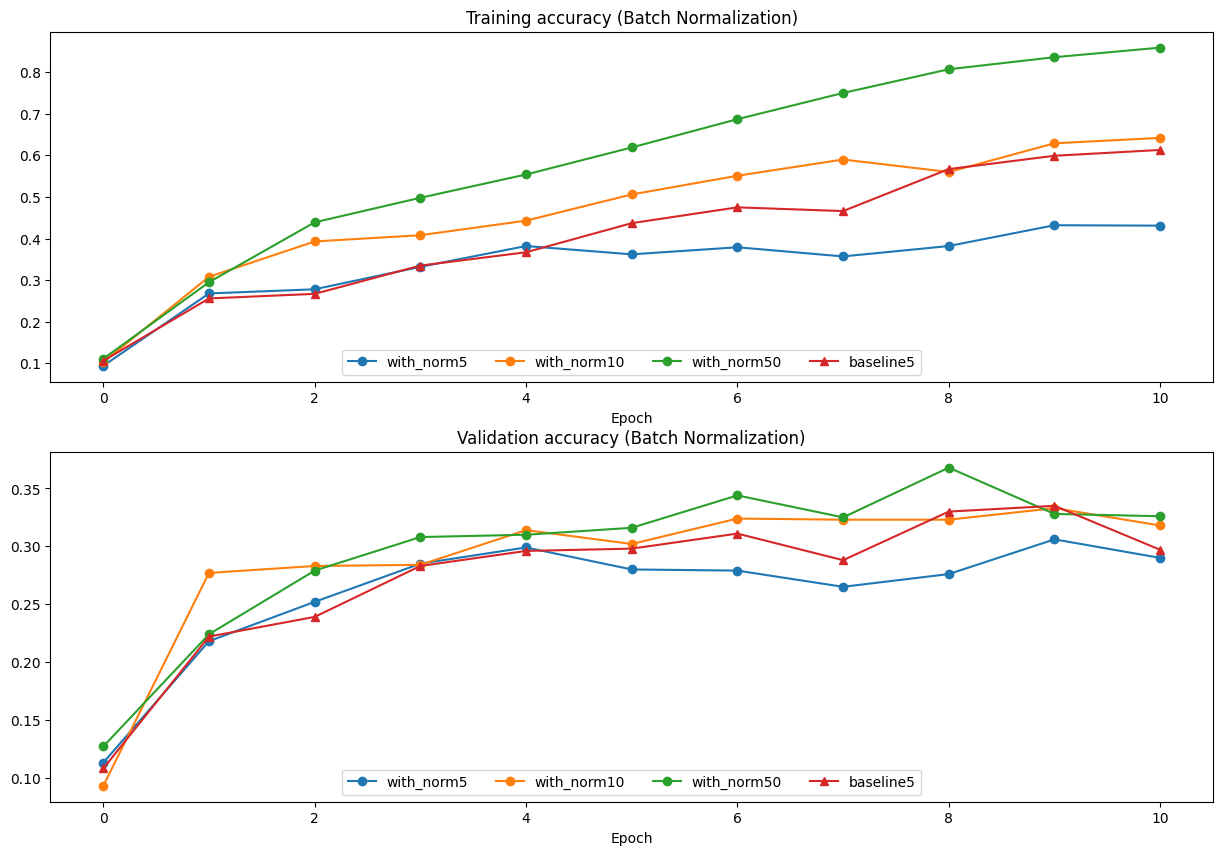

In [15]:
plt.subplot(2, 1, 1)
plot_training_history('Training accuracy (Batch Normalization)','Epoch', solver_bsize, bn_solvers_bsize, \
                      lambda x: x.train_acc_history, bl_marker='-^', bn_marker='-o', labels=batch_sizes)
plt.subplot(2, 1, 2)
plot_training_history('Validation accuracy (Batch Normalization)','Epoch', solver_bsize, bn_solvers_bsize, \
                      lambda x: x.val_acc_history, bl_marker='-^', bn_marker='-o', labels=batch_sizes)

plt.gcf().set_size_inches(15, 10)
plt.show()

## 内联问题 2：

描述该实验的结果。这说明批量归一化与批量大小之间存在怎样的关系？为什么会观察到这种关系？

## 回答：

[FILL THIS IN]


# 层归一化

实践证明，批量归一化能有效地使网络更易训练，但它对批量大小的依赖，使其在一些复杂网络中不那么实用；受硬件限制，这些网络的输入批量大小存在上限。

为缓解这一问题，人们提出了多种批量归一化的替代方案，其中一种是层归一化（Layer Normalization）[2]。我们不再对批量维度进行归一化，而是对特征进行归一化。换句话说，使用层归一化时，与单个数据点对应的每个特征向量，都基于该特征向量中所有项的总和进行归一化。

[2] [Ba, Jimmy Lei, Jamie Ryan Kiros, and Geoffrey E. Hinton. “Layer Normalization.” stat 1050 (2016): 21.](https://arxiv.org/pdf/1607.06450.pdf)

## 内联问题 3：

以下哪些数据预处理步骤类似于批量归一化，哪些类似于层归一化？

1. 对数据集中的每幅图像进行缩放，使图像中每一行像素的 RGB 通道之和为 1。
2. 对数据集中的每幅图像进行缩放，使图像中所有像素的 RGB 通道之和为 1。  
3. 从数据集中的每幅图像中减去该数据集的平均图像。
4. 根据给定阈值，将所有 RGB 值设为 0 或 1。

## 回答：

[FILL THIS IN]


# 层归一化：实现

现在你将实现层归一化。这个步骤应该相对直接，因为从概念上看，其实现与批量归一化几乎完全相同。不过，一个显著区别是：层归一化不跟踪滑动统计量，并且测试阶段与训练阶段相同，均值和方差都直接按每个数据点计算。

你需要完成以下工作：

* 在 `cs231n/layers.py` 中，实现函数 `layernorm_forward` 的层归一化前向传播。

运行下面的单元检查结果。
* 在 `cs231n/layers.py` 中，实现函数 `layernorm_backward` 的层归一化反向传播。

运行下面的第二个单元检查结果。
* 修改 `cs231n/classifiers/fc_net.py`，为 `FullyConnectedNet` 添加层归一化。当构造函数中的 `normalization` 标志被设为 `"layernorm"` 时，应在每个 ReLU 非线性之前插入一个层归一化层。

运行下面的第三个单元，对层归一化执行批量大小实验。

In [16]:
# Check the training-time forward pass by checking means and variances
# of features both before and after layer normalization.

# Simulate the forward pass for a two-layer network.
np.random.seed(231)
N, D1, D2, D3 =4, 50, 60, 3
X = np.random.randn(N, D1)
W1 = np.random.randn(D1, D2)
W2 = np.random.randn(D2, D3)
a = np.maximum(0, X.dot(W1)).dot(W2)

print('Before layer normalization:')
print_mean_std(a,axis=1)

gamma = np.ones(D3)
beta = np.zeros(D3)

# Means should be close to zero and stds close to one.
print('After layer normalization (gamma=1, beta=0)')
a_norm, _ = layernorm_forward(a, gamma, beta, {'mode': 'train'})
print_mean_std(a_norm,axis=1)

gamma = np.asarray([3.0,3.0,3.0])
beta = np.asarray([5.0,5.0,5.0])

# Now means should be close to beta and stds close to gamma.
print('After layer normalization (gamma=', gamma, ', beta=', beta, ')')
a_norm, _ = layernorm_forward(a, gamma, beta, {'mode': 'train'})
print_mean_std(a_norm,axis=1)

Before layer normalization:
  means: [-59.06673243 -47.60782686 -43.31137368 -26.40991744]
  stds:  [10.07429373 28.39478981 35.28360729  4.01831507]

After layer normalization (gamma=1, beta=0)
  means: [ 4.81096644e-16  0.00000000e+00  0.00000000e+00 -2.96059473e-16]
  stds:  [0.99999995 0.99999999 1.         0.99999969]

After layer normalization (gamma= [3. 3. 3.] , beta= [5. 5. 5.] )
  means: [5. 5. 5. 5.]
  stds:  [2.99999985 2.99999998 2.99999999 2.99999907]



In [17]:
# Gradient check batchnorm backward pass.
np.random.seed(231)
N, D = 4, 5
x = 5 * np.random.randn(N, D) + 12
gamma = np.random.randn(D)
beta = np.random.randn(D)
dout = np.random.randn(N, D)

ln_param = {}
fx = lambda x: layernorm_forward(x, gamma, beta, ln_param)[0]
fg = lambda a: layernorm_forward(x, a, beta, ln_param)[0]
fb = lambda b: layernorm_forward(x, gamma, b, ln_param)[0]

dx_num = eval_numerical_gradient_array(fx, x, dout)
da_num = eval_numerical_gradient_array(fg, gamma.copy(), dout)
db_num = eval_numerical_gradient_array(fb, beta.copy(), dout)

_, cache = layernorm_forward(x, gamma, beta, ln_param)
dx, dgamma, dbeta = layernorm_backward(dout, cache)

# You should expect to see relative errors between 1e-12 and 1e-8.
print('dx error: ', rel_error(dx_num, dx))
print('dgamma error: ', rel_error(da_num, dgamma))
print('dbeta error: ', rel_error(db_num, dbeta))

dx error:  2.107279036881856e-09
dgamma error:  4.519489546032799e-12
dbeta error:  2.5842537629899423e-12


# 层归一化与批量大小

现在，我们将使用层归一化而不是批量归一化，重新运行之前的批量大小实验。与上一个实验相比，你应该会看到批量大小对训练过程的影响明显更小！

No normalization: batch size =  5
Normalization: batch size =  5
Normalization: batch size =  10
Normalization: batch size =  50


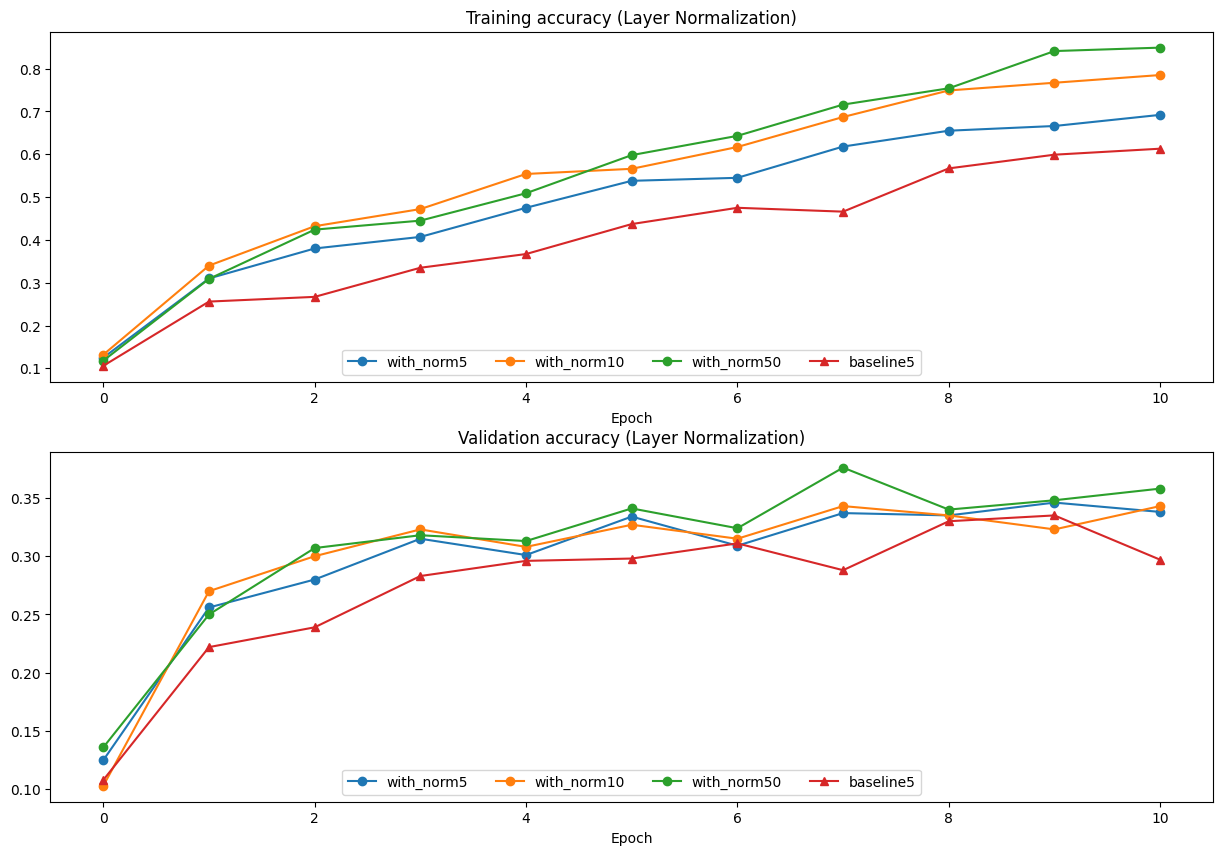

In [18]:
ln_solvers_bsize, solver_bsize, batch_sizes = run_batchsize_experiments('layernorm')

plt.subplot(2, 1, 1)
plot_training_history('Training accuracy (Layer Normalization)','Epoch', solver_bsize, ln_solvers_bsize, \
                      lambda x: x.train_acc_history, bl_marker='-^', bn_marker='-o', labels=batch_sizes)
plt.subplot(2, 1, 2)
plot_training_history('Validation accuracy (Layer Normalization)','Epoch', solver_bsize, ln_solvers_bsize, \
                      lambda x: x.val_acc_history, bl_marker='-^', bn_marker='-o', labels=batch_sizes)

plt.gcf().set_size_inches(15, 10)
plt.show()

## 内联问题 4：

层归一化在什么情况下可能效果不佳？为什么？

1. 在非常深的网络中使用它
2. 特征维度非常小
3. 正则化项很大


## 回答：

[FILL THIS IN]
